In [10]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split 
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve
)

import joblib

data = load_breast_cancer()

In [11]:
print(data.DESCR)

.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

    :Number of Instances: 569

    :Number of Attributes: 30 numeric, predictive attributes and the class

    :Attribute Information:
        - radius (mean of distances from center to points on the perimeter)
        - texture (standard deviation of gray-scale values)
        - perimeter
        - area
        - smoothness (local variation in radius lengths)
        - compactness (perimeter^2 / area - 1.0)
        - concavity (severity of concave portions of the contour)
        - concave points (number of concave portions of the contour)
        - symmetry
        - fractal dimension ("coastline approximation" - 1)

        The mean, standard error, and "worst" or largest (mean of the three
        worst/largest values) of these features were computed for each image,
        resulting in 30 features.  For instance, field 0 is Mean Radi

In [12]:
df = pd.DataFrame(data.data, columns = data.feature_names)

df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Basic EDA

In [13]:
print(f"Dataset Shape: {df.shape}")
print(f"Column Information: {df.info()}")
print(f"Missing Values: {df.isnull().sum()}")
print(f"Descriptive Statistics: {df.describe()}")

Dataset Shape: (569, 30)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perimeter error          569 non-null    float64
 13  area error               569 non-null    float64
 14  s

## Target Distribution

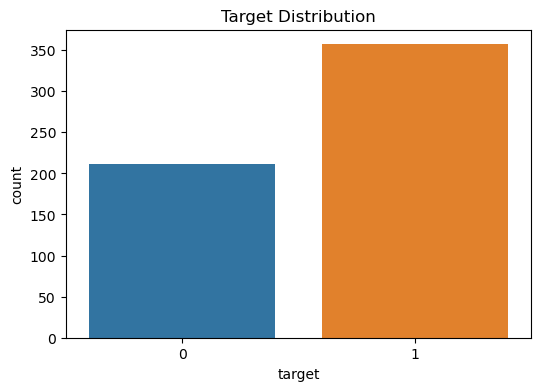

In [15]:
df['target'] = data.target

plt.figure(figsize = (6, 4))

sns.countplot(x = "target", data = df)

plt.title("Target Distribution")
plt.show()

## Feature Distributing

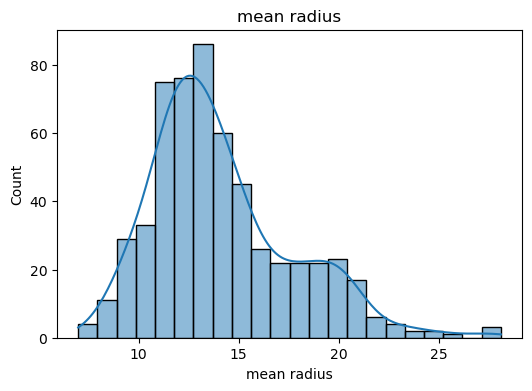

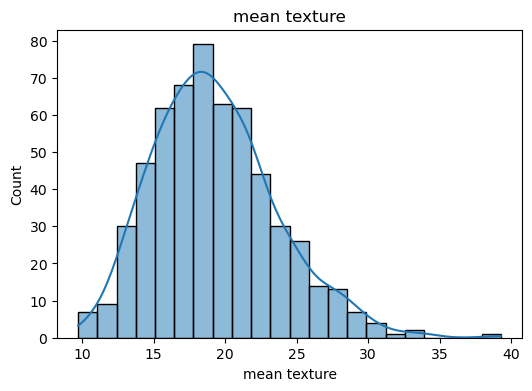

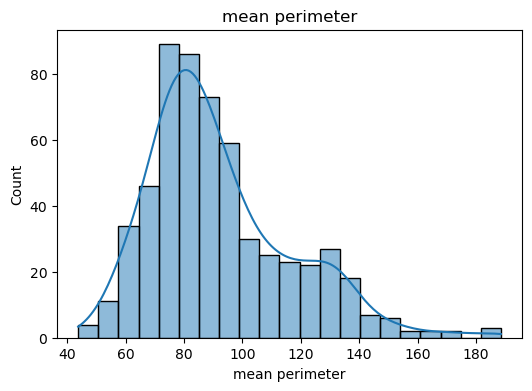

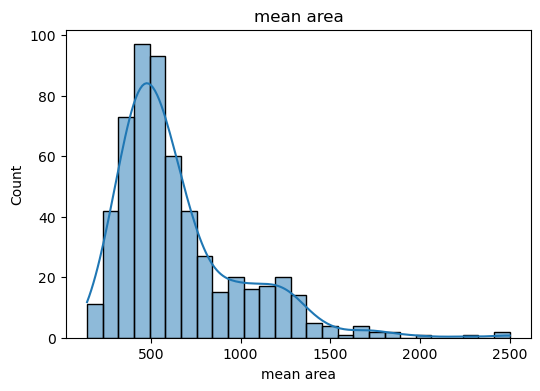

In [16]:
features = [
    'mean radius',
    'mean texture',
    'mean perimeter',
    'mean area'
]

for feature in features:
    plt.figure(figsize = (6, 4))

    sns.histplot(df[feature], kde = True)

    plt.title(feature)
    plt.show()

## Feature and Target

In [18]:
X = df.drop("target", axis = 1)
Y = df["target"]

## Train Test Split

In [19]:
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size = 0.2, random_state = 42)

print(f"Train Shape: {x_train.shape}")
print(f"Test Shape: {x_test.shape}")

Train Shape: (455, 30)
Test Shape: (114, 30)


## Feature Scaling

In [20]:
scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)

x_test_scaled = scaler.transform(x_test)

## Model Creation

In [23]:
model = LogisticRegression(C = 1.0, penalty = 'l2', max_iter = 1000, random_state = 42)

## Train Model

In [24]:
model.fit(x_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

## Predictions

In [25]:
y_pred = model.predict(x_test_scaled)

y_prob = model.predict_proba(x_test_scaled)[:, 1]

## Evaluation Metrics

In [26]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred)

print("MODEL PERFORMANCE")

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"ROC AUC: {auc:.4f}")


MODEL PERFORMANCE
Accuracy: 0.9737
Precision: 0.9722
Recall: 0.9859
F1 Score: 0.9790
ROC AUC: 0.9697


## Classification Report

In [27]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Confusion Matrix

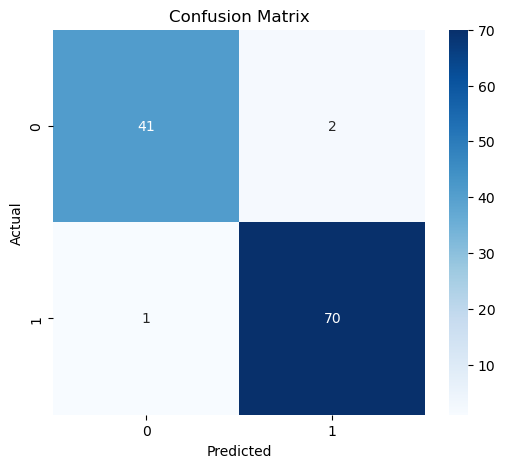

In [28]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize = (6, 5))

sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

## ROC Curve

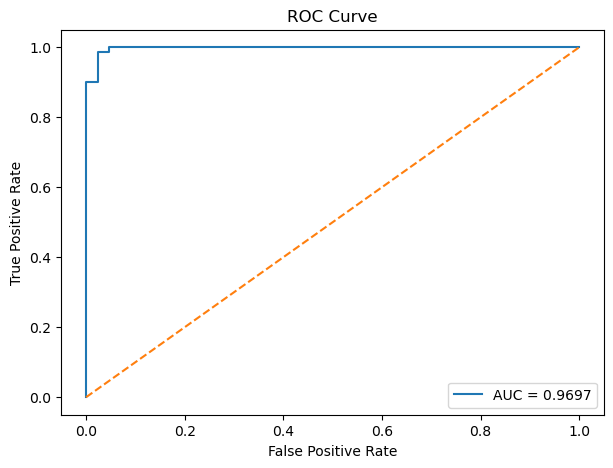

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize = (7, 5))

plt.plot(fpr, tpr, label = f"AUC = {auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle = "--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

## Feature Importance

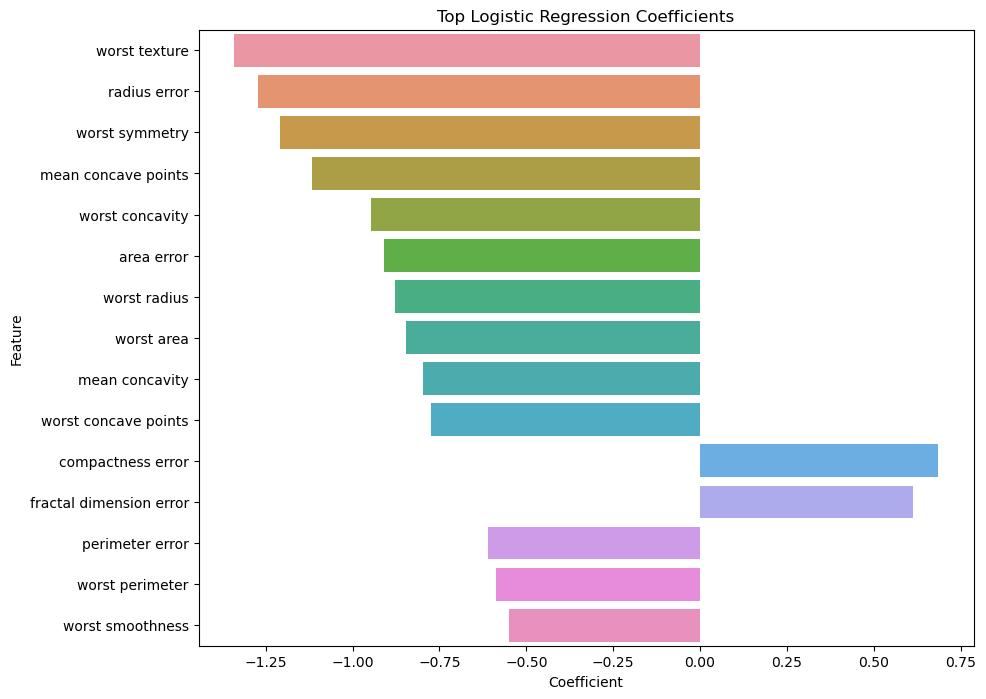

In [32]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

importance["Absolute"] = (importance["Coefficient"].abs())

importance = importance.sort_values(by = "Absolute", ascending = False)

plt.figure(figsize = (10,8))

sns.barplot(data = importance.head(15),
    x = "Coefficient",
    y = "Feature"
)
plt.title("Top Logistic Regression Coefficients")
plt.show()

## Save Model

In [34]:
joblib.dump(model, "logistic_regression_model.pkl")

joblib.dump(scaler, "standard_scaler.pkl")

['standard_scaler.pkl']